# LSTM — Multiple Series

One model trained across many series at once. This is the shape real production forecasting takes:
nobody fits four thousand models by hand.

| | |
|---|---|
| **Course section** | LSTM - Multiple Time Series Forecasting |
| **Data** | `Hourly-train.csv` (M4 competition), `best_params_lstm.csv` |
| **Libraries** | `darts` (`RNNModel`), `torch` |
| **Runs on** | GPU strongly recommended |

> **Turn the GPU on before you run this.** In Colab: `Runtime → Change runtime type → T4 GPU`.
> On CPU these cells finish eventually, but not in a sitting.

> This notebook is larger than GitHub's 5 MB preview limit and will not render on github.com.
> Open it in Colab or clone the repository.

## Roadmap

1. Libraries and data, GPU on
2. Build a list of Darts `TimeSeries`, one per series
3. Exploratory analysis across the set
4. Create time covariates that apply to every series
5. Fit a single `RNNModel` on the whole list
6. Cross-validate
7. Tune
8. Predict the future for every series

## Global models

Passing a list of series to `fit()` instead of one series trains a **global** model: the same weights
are shared across all of them. Each series alone might be too short to learn from, but together they
have plenty of signal, and a pattern learned on one transfers to the rest.

The trade-off is that the model now has to serve every series, so an unusual one gets averaged into
the crowd. Static covariates are how you tell the model which series is which.

---

Part of **[Master Time Series Analysis and Forecasting with Python](https://www.udemy.com/course/forecasting-python/?referralCode=63045C9CC807EB1EBD9A)** · [All notebooks](https://github.com/diogoalvesderesende/time-series-forecasting-python)

# Libraries and Data (TURN ON GPU)

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Path to the folder
%cd /content/drive/MyDrive/Freelance/DataHeroes/Course/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/Multiple Series-LSTM

/content/drive/MyDrive/Freelance/DataHeroes/Course/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/Multiple Series-LSTM


In [3]:
# Install the darts library
!pip install -q "darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.8/808.8 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.4 MB/s eta 0:00:00


In [4]:
# Standard Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

# Darts functions
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel

In [5]:
# Load the CSV data into a NumPy array
df = pd.read_csv("Hourly-train.csv", header = None).values.squeeze()
df

array([['V1', 'V2', 'V3', ..., 'V959', 'V960', 'V961'],
       ['H1', '605', '586', ..., nan, nan, nan],
       ['H2', '3124', '2990', ..., nan, nan, nan],
       ...,
       ['H412', '19', '30', ..., '73', '39', '36'],
       ['H413', '21', '16', ..., '53', '38', '46'],
       ['H414', '15', '13', ..., '35', '26', '17']], dtype=object)

In [6]:
df.shape

(415, 961)

In [7]:
# Excluding the first row and first column
df = df[1:, 1:].astype(np.float64)
df

array([[ 605.,  586.,  586., ...,   nan,   nan,   nan],
       [3124., 2990., 2862., ...,   nan,   nan,   nan],
       [1828., 1806., 1897., ...,   nan,   nan,   nan],
       ...,
       [  19.,   30.,   12., ...,   73.,   39.,   36.],
       [  21.,   16.,   17., ...,   53.,   38.,   46.],
       [  15.,   13.,   13., ...,   35.,   26.,   17.]])

In [8]:
df.shape

(414, 960)

In [9]:
# Transpose the data
df = df.T
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [  nan,   nan,   nan, ...,   73.,   53.,   35.],
       [  nan,   nan,   nan, ...,   39.,   38.,   26.],
       [  nan,   nan,   nan, ...,   36.,   46.,   17.]])

In [10]:
df.shape

(960, 414)

In [11]:
# Check which wos have nan values
na_rows = np.isnan(df).any(axis = 1)
np.where(na_rows)

(array([700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712,
        713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725,
        726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738,
        739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751,
        752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764,
        765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777,
        778, 779, 780, 781, 782, 783, 784, 785, 786, 787, 788, 789, 790,
        791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803,
        804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816,
        817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829,
        830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840, 841, 842,
        843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853, 854, 855,
        856, 857, 858, 859, 860, 861, 862, 863, 864, 865, 866, 867, 868,
        869, 870, 871, 872, 873, 874, 875, 876, 877

In [12]:
# Remove the columns with NaN value
df = df[~na_rows]
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [ 752., 3460., 1581., ...,   18.,   17.,   13.],
       [ 739., 3248., 1570., ...,   13.,   16.,   17.],
       [ 684., 3105., 1518., ...,   17.,   15.,   21.]])

In [13]:
# Display how many time series
len(df)

700

In [14]:
# Preview df shape
df.shape

(700, 414)

# Time Series object

In [15]:
# Create a pandas df
df_pd = pd.DataFrame(df)
df_pd.head()

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
0,605.0,3124.0,1828.0,6454.0,4263.0,5780.0,52817.0,32479.0,39455.0,513.0,...,68.0,21.0,214.0,19.0,31.0,153.0,24.0,19.0,21.0,15.0
1,586.0,2990.0,1806.0,6324.0,4297.0,5497.0,51773.0,31018.0,38279.0,512.0,...,48.0,15.0,238.0,31.0,39.0,196.0,30.0,30.0,16.0,13.0
2,586.0,2862.0,1897.0,6075.0,4236.0,5306.0,50907.0,30033.0,36944.0,506.0,...,33.0,15.0,130.0,25.0,22.0,163.0,22.0,12.0,17.0,13.0
3,559.0,2809.0,1750.0,5949.0,4080.0,5178.0,50224.0,27716.0,35984.0,500.0,...,21.0,17.0,69.0,23.0,17.0,131.0,14.0,16.0,19.0,16.0
4,511.0,2544.0,1679.0,5858.0,3883.0,5235.0,49496.0,25067.0,33721.0,490.0,...,30.0,15.0,68.0,14.0,13.0,82.0,19.0,13.0,16.0,26.0


In [16]:
# Create a dummy starting date with hour
start_date = pd.Timestamp("2000-01-01 00:00:00")

In [17]:
# Create the Time Series object
series = TimeSeries.from_times_and_values(
    times = pd.date_range(start_date, periods = df_pd.shape[0], freq = "h"),
    values = df_pd.values
)

# Exploratory Data Analysis

<Figure size 1500x500 with 0 Axes>

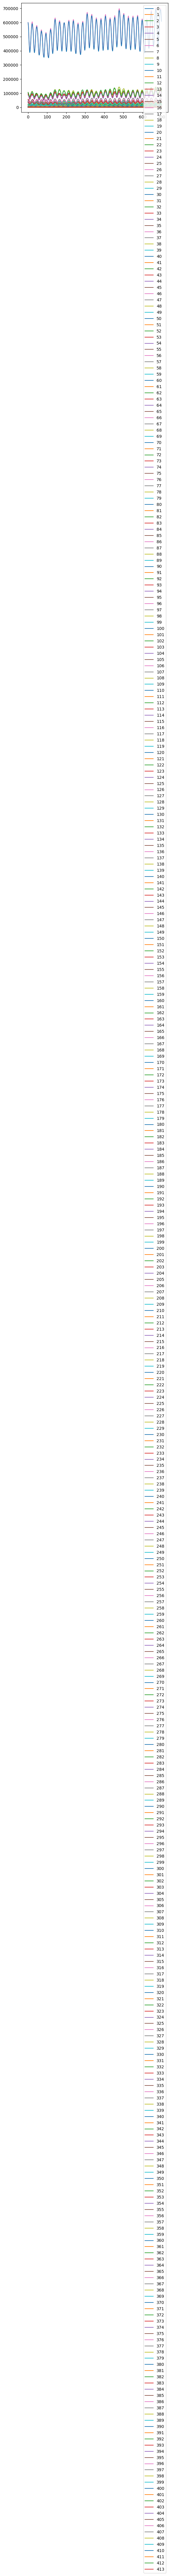

In [18]:
# Simple plot
plt.figure(figsize = (15, 5))
df_pd.plot()
plt.show()

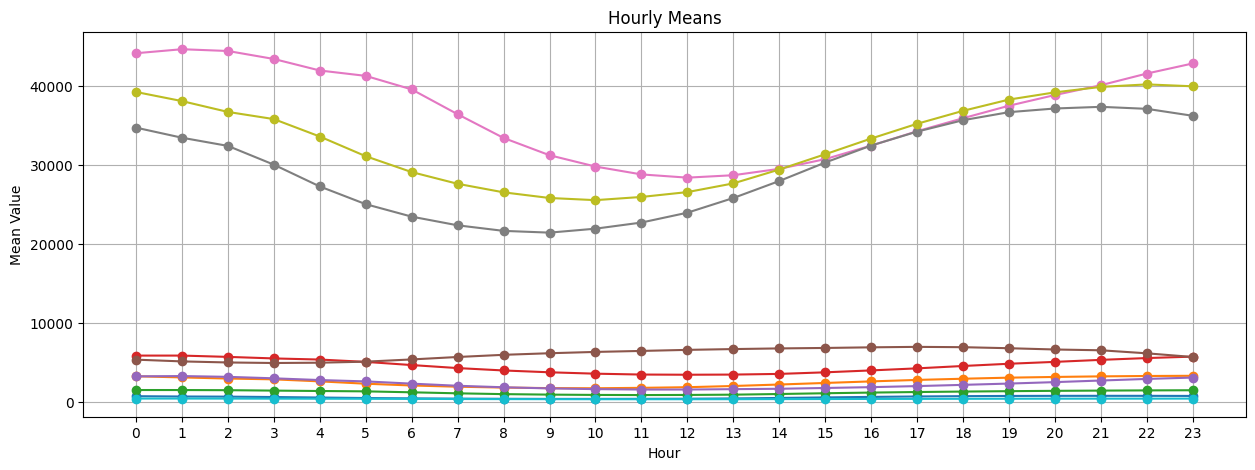

In [19]:
# Daily Seasonalities
df_with_time = series.to_dataframe()

# Compute the hourly means
hourly_means= df_with_time.groupby(df_with_time.index.hour).mean()

# Plot the hourly means
plt.figure(figsize = (15, 5))
plt.plot(hourly_means.iloc[:,0:10], marker = "o")
plt.grid()
plt.title("Hourly Means")
plt.xlabel("Hour")
plt.ylabel("Mean Value")
plt.xticks(range(24))
plt.show()

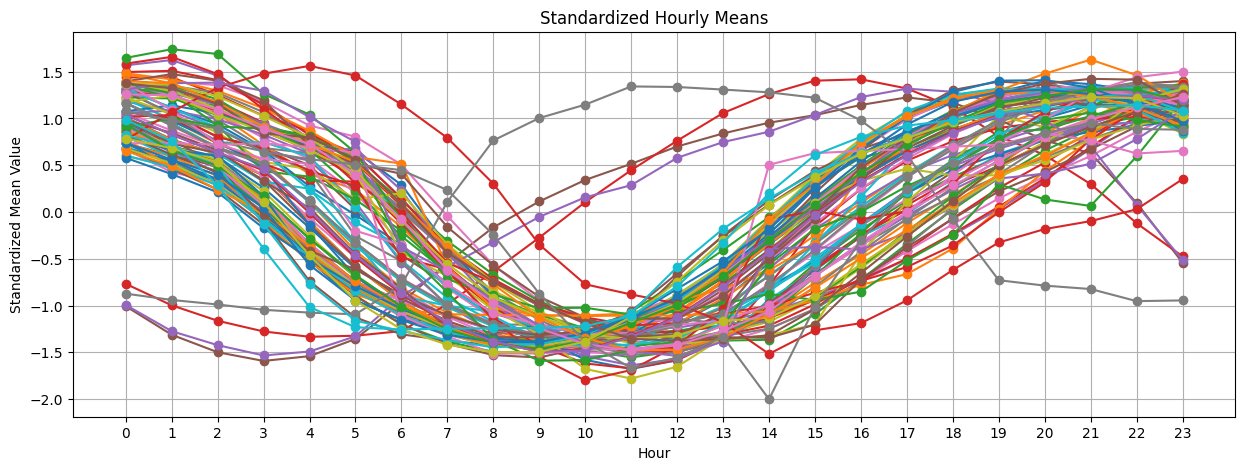

In [ ]:
# Standardize the hourly means
hourly_means_std = (hourly_means - hourly_means.mean()) / hourly_means.std()

# Plot the standardized hourly means
plt.figure(figsize = (15, 5))
plt.plot(hourly_means_std.iloc[:,0:100], marker = "o")
plt.grid()
plt.title("Standardized Hourly Means")
plt.xlabel("Hour")
plt.ylabel("Standardized Mean Value")
plt.xticks(range(24))
plt.show()

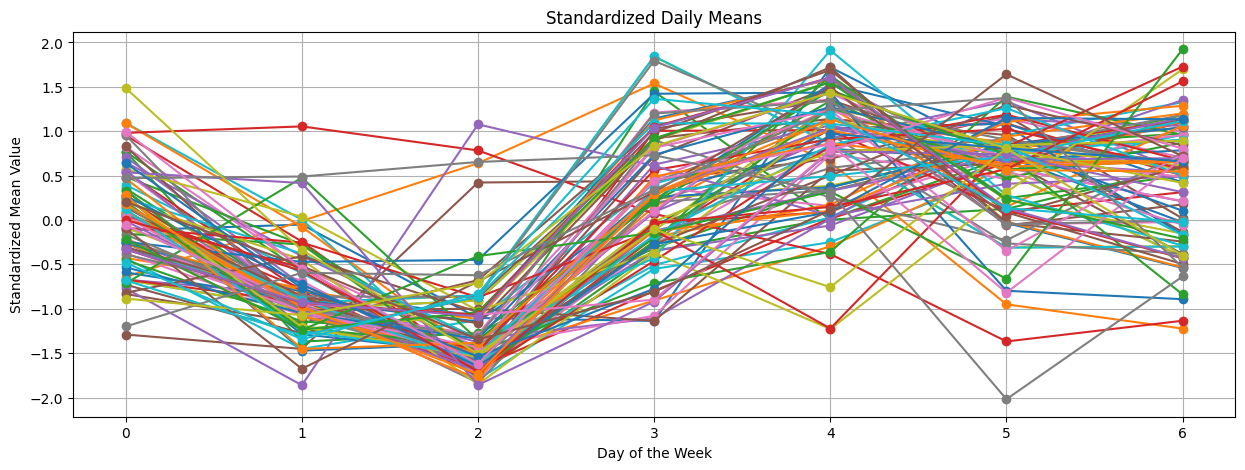

In [ ]:
# Compute the daily means for the weekly seasonality
daily_means = df_with_time.groupby(df_with_time.index.dayofweek).mean()
# Standardize the daily values
daily_means_std = (daily_means - daily_means.mean()) / daily_means.std()

# Plot the values
plt.figure(figsize = (15, 5))
plt.plot(daily_means_std.iloc[:,0:100], marker = "o")
plt.grid()
plt.title("Standardized Daily Means")
plt.xlabel("Day of the Week")
plt.ylabel("Standardized Mean Value")
plt.xticks(range(7))
plt.show()

# Creating the time series covariates

In [ ]:
# create a time series instance for hour and weekday
hour_series = datetime_attribute_timeseries(
    series,
    attribute = "hour",
    one_hot = True
)
weekday_series = datetime_attribute_timeseries(
    series,
    attribute = "dayofweek",
    one_hot = True
)

In [ ]:
# Import the Scaler and fit transform the series
scaler = Scaler()
series_scaled = scaler.fit_transform(series)
series_scaled

,0,1,2,3,4,...,409,410,411,412,413
2000-01-01 00:00:00,0.443674,0.650962,0.931291,1.000000,0.962329,...,0.561475,0.036496,0.021407,0.093458,0.006932
2000-01-01 01:00:00,0.410745,0.598351,0.910864,0.962772,0.973973,...,0.737705,0.058394,0.055046,0.046729,0.003466
2000-01-01 02:00:00,0.410745,0.548096,0.995357,0.891466,0.953082,...,0.602459,0.029197,0.000000,0.056075,0.003466
2000-01-01 03:00:00,0.363951,0.527287,0.858867,0.855384,0.899658,...,0.471311,0.000000,0.012232,0.074766,0.008666
2000-01-01 04:00:00,0.280763,0.423243,0.792943,0.829324,0.832192,...,0.270492,0.018248,0.003058,0.046729,0.025997
...,...,...,...,...,...,...,...,...,...,...,...
2000-01-29 23:00:00,0.764298,0.879073,0.642526,0.744845,0.942466,...,0.168033,0.138686,0.051988,0.084112,0.010399
2000-01-30 00:00:00,0.753899,0.858265,0.691736,0.795246,0.976027,...,0.098361,0.029197,0.018349,0.112150,0.010399
2000-01-30 01:00:00,0.698440,0.782882,0.701950,0.801260,1.000000,...,0.106557,0.007299,0.018349,0.056075,0.003466
2000-01-30 02:00:00,0.675910,0.699647,0.691736,0.744559,0.964726,...,0.053279,0.014599,0.003058,0.046729,0.010399


In [ ]:
# Stack the covariates
covariates = hour_series.stack(weekday_series)

# LSTM Model

In [ ]:
# Define the input chunk length, forecasting horizon and training length
chunk_length = 48
forecast_horizon = 24
training_length = chunk_length + forecast_horizon

In [ ]:
# Build the LSTM Model
model = RNNModel(
    model = "LSTM",
    hidden_dim = 25,
    n_rnn_layers = 2,
    dropout = 0.1,
    n_epochs = 10,
    random_state = 1502,
    training_length = training_length,
    input_chunk_length = chunk_length,
    optimizer_kwargs = {"lr": 0.003},
    pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
)
model.fit(series_scaled, future_covariates = covariates)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 52.4 K | train
6 | V               | Linear           | 10.8 K | train
-------------------------------------------------------------
63.2 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=25, n_rnn_layers=2, dropout=0.1, training_length=72, n_epochs=10, random_state=1502, input_chunk_length=48, optimizer_kwargs={'lr': 0.003}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

# Cross Validation

In [ ]:
forecast_horizon / 2

12.0

In [ ]:
# Perform Cross-validation
cv = model.historical_forecasts(
    series = series_scaled,
    future_covariates = covariates,
    start = (df.shape[0] - (forecast_horizon * 10)),
    forecast_horizon = forecast_horizon,
    stride = int(forecast_horizon / 2),
    retrain = True,
    last_points_only = False,
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 52.4 K | train
6 | V               | Linear           | 10.8 K | train
-------------------------------------------------------------
63.2 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 52.4 K | train
6 | V               | Linear           | 10.8 K | train
-------------------------------------------------------------
63.2 K    Trainable params
0         Non-trainable p

...

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 52.4 K | train
6 | V               | Linear           | 10.8 K | train
-------------------------------------------------------------
63.2 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Check the performance of the CV
rmse_cv = []

# Iterate through the CVs
for i in range(len(cv)):
  predictions = TimeSeries.to_dataframe(scaler.inverse_transform(cv[i]))

  # Conver the series to pandas
  df_pandas = TimeSeries.to_dataframe(series)

  # Determine the start and end index
  start_cv = predictions.index.min()
  end_cv = predictions.index.max()
  actuals = df_pandas[start_cv:end_cv]

  # Compute the RMSE
  rmse = root_mean_squared_error(actuals, predictions)
  rmse_cv.append(rmse)

# Display the outcome
print(f"The RMSE is {np.mean(rmse_cv):.1f}")

The RMSE is 562.1


In [ ]:
# Visualize the CV
for i in range(len(cv)):
  plt.figure(figsize=(15,5))

  # Plot the predicted values from the current fold
  scaler.inverse_transform(cv[i]).plot(label = "Predicted", max_nr_components = 4)

  # Plot the actual values from the current fold
  series.plot(label = "actuals", max_nr_components = 4)

  # Add legend and title
  plt.legend()
  plt.title(f"Fold {i + 1}")
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Parameter Tuning

In [ ]:
# Define the param grid
param_grid = {
    "n_rnn_layers": [2, 3],
    "hidden_dim": [20, 25],
    "dropout": [0.05, 0.1],
    "n_epochs": [10, 15],
    "lr": [0.003, 0.005],
    "training_length": [72, 96],
    "input_chunk_length": [48, 72]
}
grid = ParameterGrid(param_grid)
len(list(grid))

128

In [ ]:
# Initialize the rmse_list
rmse_list = []

# Iterate through the grid
for params in grid:
  # Create the model
  model = RNNModel(
      model = "LSTM",
      n_rnn_layers = params["n_rnn_layers"],
      hidden_dim = params["hidden_dim"],
      dropout = params["dropout"],
      n_epochs = params["n_epochs"],
      random_state = 1502,
      training_length = params["training_length"],
      optimizer_kwargs = {"lr": params["lr"]},
      input_chunk_length = params["input_chunk_length"],
      pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
    )

  # Cross-validation and result iteration
  cv = model.historical_forecasts(
      series = series_scaled,
      future_covariates = covariates,
      start = (df.shape[0] - (forecast_horizon * 10)),
      forecast_horizon = forecast_horizon,
      stride = int(forecast_horizon / 2),
      retrain = True,
      last_points_only = False,
  )

  # Get the CV result
  rmse_cv = []
  for i in range(len(cv)):
    predictions = TimeSeries.to_dataframe(scaler.inverse_transform(cv[i]))
    df_pandas = TimeSeries.to_dataframe(series)
    start_cv = predictions.index.min()
    end_cv = predictions.index.max()
    actuals = df_pandas[start_cv:end_cv]
    rmse = root_mean_squared_error(actuals, predictions)
    rmse_cv.append(rmse)

  # Store the result
  rmse_list.append(np.mean(rmse_cv))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Attach the RMSE to the param grid and display
results = pd.DataFrame(grid)
results["RMSE"] = rmse_list
results

In [ ]:
# export the best params
best_params = results.sort_values(by = "RMSE").iloc[0]
best_params.to_csv("best_params_lstm.csv")

# Predicting the future

In [ ]:
# Importing the best params
best_params = pd.read_csv("best_params_lstm.csv", index_col = 0)
best_params

,124
dropout,0.100000
hidden_dim,25.000000
input_chunk_length,72.000000
lr,0.005000
n_epochs,15.000000
n_rnn_layers,2.000000
training_length,72.000000
RMSE,517.016058


In [ ]:
# isolate each of the best params in its required data type
n_rnn_layers = int(best_params.loc["n_rnn_layers"].iloc[0])
hidden_dim = int(best_params.loc["hidden_dim"].iloc[0])
dropout = float(best_params.loc["dropout"].iloc[0])
n_epochs = int(best_params.loc["n_epochs"].iloc[0])
lr = float(best_params.loc["lr"].iloc[0])
training_length = int(best_params.loc["training_length"].iloc[0])
input_chunk_length = int(best_params.loc["input_chunk_length"].iloc[0])

In [ ]:
# Generate the future index time from one hour after our data
future_time_index = pd.date_range(
    start = series.end_time() + pd.Timedelta("1h"),
    periods = forecast_horizon,
    freq = "h"
)

In [ ]:
# Create the Time series objects for the hourly and weekdays
hour_future = datetime_attribute_timeseries(
    future_time_index,
    attribute = "hour",
    one_hot = True
)
weekday_future = datetime_attribute_timeseries(
    future_time_index,
    attribute = "dayofweek",
    one_hot = True
)

In [ ]:
series_scaled

<TimeSeries (time: 700, component: 414, sample: 1)> Size: 2MB
array([[[0.44367418],
        [0.65096192],
        [0.93129062],
        ...,
        [0.02140673],
        [0.09345794],
        [0.00693241]],

       [[0.41074523],
        [0.598351  ],
        [0.91086351],
        ...,
        [0.05504587],
        [0.04672897],
        [0.0034662 ]],

       [[0.41074523],
        [0.5480958 ],
        [0.99535747],
        ...,
...
        ...,
        [0.01834862],
        [0.05607477],
        [0.0034662 ]],

       [[0.67590988],
        [0.69964664],
        [0.6917363 ],
        ...,
        [0.0030581 ],
        [0.04672897],
        [0.01039861]],

       [[0.58058925],
        [0.64350216],
        [0.64345404],
        ...,
        [0.01529052],
        [0.03738318],
        [0.01733102]]])
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-30T03:00:00
  * component  (component) object 3kB '0' '1' '2' '3' ... '411' '412' '413'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
covariates

<TimeSeries (time: 724, component: 31, sample: 1)> Size: 180kB
array([[[1.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]],

       [[0.],
        [1.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]],

       [[0.],
        [0.],
        [1.],
        ...,
...
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [1.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]])
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-31T03:00:00
  * component  (component) object 248B 'hour_0' 'hour_1' ... 'dayofweek_6'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Stack the future covariates
future_covariates = hour_future.stack(weekday_future)
covariates = covariates.append(future_covariates)

In [ ]:
# Build the tuned LSMT Model
tuned_model = RNNModel(
    model = "LSTM",
    hidden_dim=hidden_dim,
    n_rnn_layers=n_rnn_layers,
    dropout=dropout,
    n_epochs=n_epochs,
    random_state=1502,
    training_length=training_length,
    input_chunk_length=input_chunk_length,
    optimizer_kwargs={"lr": lr},
    pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]},
)
tuned_model.fit(series_scaled, future_covariates=covariates)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 52.4 K | train
6 | V               | Linear           | 10.8 K | train
-------------------------------------------------------------
63.2 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


RNNModel(model=LSTM, hidden_dim=25, n_rnn_layers=2, dropout=0.1, training_length=72, n_epochs=15, random_state=1502, input_chunk_length=72, optimizer_kwargs={'lr': 0.005}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

In [ ]:
# Make the predictions with the tuned model
predictions = tuned_model.predict(
    n = forecast_horizon,
    future_covariates = covariates # Use the combined covariates
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Transform the predictions into a df
predictions_df = TimeSeries.to_dataframe(scaler.inverse_transform(predictions))
predictions_df

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
2000-01-30 04:00:00,670.415536,3035.784481,1409.272061,5600.792640,3054.140699,4852.417256,43738.166505,29694.057283,36700.253372,448.665404,...,-3.563954,11.474313,-57.145674,58.547891,-10.991232,40.071930,26.653462,7.314565,16.560979,15.014127
2000-01-30 05:00:00,625.858002,2807.131754,1369.740001,5440.559317,2912.305292,4914.095550,42498.375186,27687.323930,35005.908434,445.944189,...,-4.433042,17.285662,-47.810184,81.625121,-10.312134,42.670057,37.345970,5.415559,13.961716,19.251382
2000-01-30 06:00:00,580.094831,2570.000074,1289.181782,5172.664710,2655.942203,5163.415539,40690.778857,25643.743939,33387.485319,439.423487,...,19.230331,34.549858,69.004896,124.701355,2.519491,60.803423,67.998060,12.822453,13.266114,34.285808
2000-01-30 07:00:00,535.823877,2349.944083,1179.299502,4818.876480,2356.811570,5447.161192,38624.432898,23910.381528,31972.048012,428.764702,...,80.593364,61.766058,311.043552,178.490012,31.867622,92.029421,112.813643,36.247848,14.120235,56.381137
2000-01-30 08:00:00,500.522501,2178.799455,1059.534654,4461.329487,2087.033617,5664.921250,36292.916950,22699.883486,30504.834560,413.921658,...,135.755754,82.287783,520.294307,226.195501,60.414064,116.126033,147.154565,59.211624,16.526710,77.382133
2000-01-30 09:00:00,474.001022,2071.069574,962.270551,4182.600512,1907.514125,5837.377602,34081.874157,22026.658792,29138.351665,401.377188,...,154.992361,87.539712,564.224807,268.459880,69.257083,120.157900,152.370357,63.390413,20.546688,94.355990
2000-01-30 10:00:00,455.980958,1988.963346,903.271942,3930.205980,1778.656737,6055.701368,32067.723497,21793.064719,27991.865319,396.176304,...,180.281949,90.244054,568.996515,314.311288,73.273494,118.946041,145.373782,62.938158,26.549870,113.087314
2000-01-30 11:00:00,449.529692,1936.975182,876.358028,3715.643616,1675.166042,6277.027689,30325.642029,21886.867807,27089.804688,394.502325,...,212.076312,92.659048,577.710905,354.621355,79.013456,117.579844,135.818361,64.751939,33.135799,130.869784
2000-01-30 12:00:00,456.404532,1916.663489,875.033600,3508.798148,1581.928409,6483.321158,28949.656860,22281.036803,26487.865481,393.994716,...,264.698882,99.155021,654.205363,388.497794,94.611968,122.281983,132.836246,76.437975,39.869080,147.563928
2000-01-30 13:00:00,486.387074,1993.777300,902.734098,3440.613851,1554.038078,6633.677352,28496.957790,23469.159184,26964.764839,394.783985,...,309.091472,104.249715,732.090143,399.665607,110.544575,127.463613,130.149170,89.211278,45.945534,157.530952
